In [10]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
with open("evaluation_results.json", "r") as f:
    evaluation_data = json.load(f)

In [ ]:
# Build DataFrames from the new evaluation_results.json structure
eval_rows = []
group_rows = []

for level_str, stats in evaluation_data.items():
    level = int(level_str)
    eval_rows.append({
        "level": level,
        "correct": stats.get("correct", 0),
        "total": stats.get("total", 0),
        "acc": stats.get("acc", 0.0),
    })

    by_group = stats.get("by_rel_group", {}) or {}
    for g_name, g_stats in by_group.items():
        group_rows.append({
            "level": level,
            "rel_group": g_name,
            "correct": g_stats.get("correct", 0),
            "total": g_stats.get("total", 0),
            "acc": g_stats.get("acc", 0.0),
        })

eval_df = pd.DataFrame(eval_rows).sort_values("level").reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values(["level", "rel_group"]).reset_index(drop=True)

# Labels for plotting
eval_df["level_label"] = eval_df["level"].apply(lambda k: f"level {k}")
if not group_df.empty:
    group_df["level_label"] = group_df["level"].apply(lambda k: f"level {k}")

eval_df.head()

,correct,total,acc
0,107,301,35.548173
1,114,302,37.748344
2,191,332,57.530120
3,203,380,53.421053
4,206,390,52.820513
5,198,395,50.126582
6,204,393,51.908397


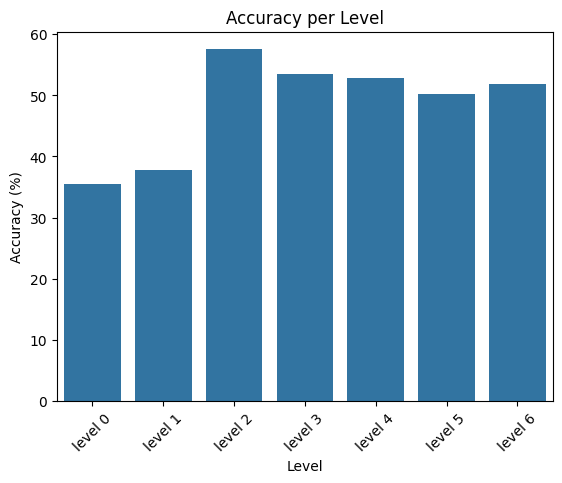

In [ ]:
# Plot 1: Overall accuracy per level
plt.figure(figsize=(8, 4))
sns.barplot(data=eval_df, x="level_label", y="acc")
plt.xlabel("Level")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Accuracy per level, split by relation group
if not group_df.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=group_df, x="level_label", y="acc", hue="rel_group")
    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy per Level by Relation Group")
    plt.xticks(rotation=45)
    plt.legend(title="rel_group")
    plt.tight_layout()
    plt.show()
else:
    print("No by_rel_group data found in evaluation_results.json")

In [ ]:
# Optional: view per-group table
group_df.head(10)